In [3]:
# ======================================================
# Cell 1: Import Required Libraries & Load Dataset
# ======================================================

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import missingno as msno

# Load Dataset
df = pd.read_csv("../data/raw/retail_transactions.csv", parse_dates=["Order_Date"])

print("=" * 50)
print("Dataset Loaded Successfully")
print("=" * 50)

print(f"Shape : {df.shape}")

display(df.head())

print("\nDataset Information")
df.info()



Dataset Loaded Successfully
Shape : (20150, 13)


,Order_ID,Order_Date,Customer_ID,Product_ID,Category,Region,Quantity,Unit_Price,Discount,Sub_Category,Sales,Cost,Profit
0,ORD100000,2024-05-10,CUST01487,PROD0029,Beauty,Central,7,29.35,0.26,Skincare,152.03,116.88,35.15
1,ORD100001,2024-11-10,CUST00042,PROD0026,Grocery,North,7,247.81,0.07,Snacks,1613.24,1080.59,532.65
2,ORD100002,2022-05-02,CUST01197,PROD0070,Beauty,East,1,365.99,0.09,Makeup,333.05,189.94,143.11
3,ORD100003,2023-04-12,CUST00679,PROD0011,Beauty,South,2,269.54,0.16,Haircare,452.83,273.79,179.04
4,ORD100004,2022-11-27,CUST01274,PROD0100,Grocery,West,5,163.63,0.13,Dairy,711.79,453.71,258.08



Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20150 entries, 0 to 20149
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order_ID      20150 non-null  object        
 1   Order_Date    20150 non-null  datetime64[ns]
 2   Customer_ID   20150 non-null  object        
 3   Product_ID    20150 non-null  object        
 4   Category      20150 non-null  object        
 5   Region        20150 non-null  object        
 6   Quantity      20150 non-null  int64         
 7   Unit_Price    19849 non-null  float64       
 8   Discount      20150 non-null  float64       
 9   Sub_Category  20150 non-null  object        
 10  Sales         20150 non-null  float64       
 11  Cost          20150 non-null  float64       
 12  Profit        20150 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(6)
memory usage: 2.0+ MB


Order_ID          0
Order_Date        0
Customer_ID       0
Product_ID        0
Category          0
Region            0
Quantity          0
Unit_Price      301
Discount          0
Sub_Category      0
Sales             0
Cost              0
Profit            0
dtype: int64


<Figure size 1200x600 with 0 Axes>

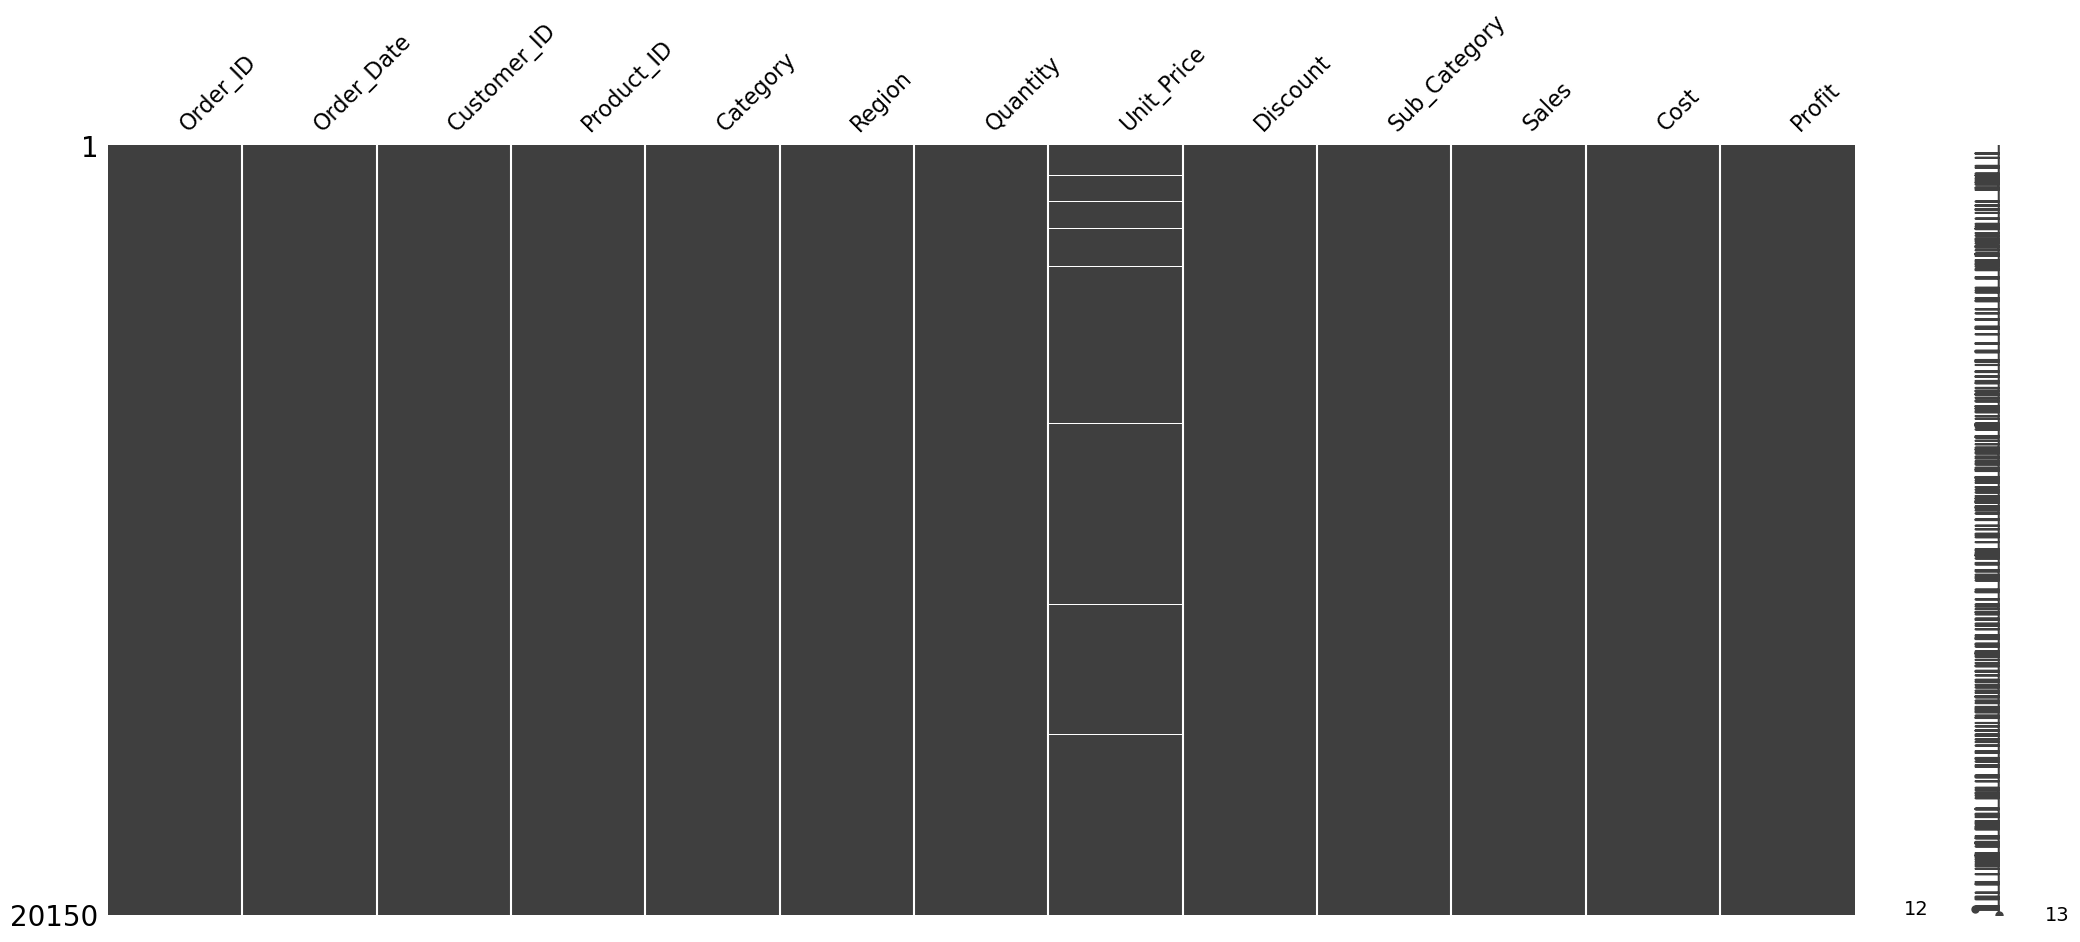

In [4]:
# ======================================================
# Cell 2: Check Missing Values
# ======================================================

print(df.isnull().sum())

plt.figure(figsize=(12,6))
msno.matrix(df)

os.makedirs("../images", exist_ok=True)

plt.savefig("../images/missing_values.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# ======================================================
# Cell 3: Remove Duplicate Records
# ======================================================

before = len(df)

df = df.drop_duplicates()

after = len(df)

print(f"Rows Before : {before}")
print(f"Rows After  : {after}")
print(f"Duplicates Removed : {before-after}")

Rows Before : 20150
Rows After  : 20000
Duplicates Removed : 150


In [6]:
# ======================================================
# Cell 4: Fill Missing Unit Price
# ======================================================

df["Unit_Price"] = (
    df.groupby("Category")["Unit_Price"]
      .transform(lambda x: x.fillna(x.median()))
)

print("Remaining Missing Values")
print(df.isnull().sum())

Remaining Missing Values
Order_ID        0
Order_Date      0
Customer_ID     0
Product_ID      0
Category        0
Region          0
Quantity        0
Unit_Price      0
Discount        0
Sub_Category    0
Sales           0
Cost            0
Profit          0
dtype: int64


In [7]:
# ======================================================
# Cell 5: Recalculate Sales, Cost & Profit
# ======================================================

df["Sales"] = (
    df["Quantity"] *
    df["Unit_Price"] *
    (1 - df["Discount"])
).round(2)

# Assume Cost = 65% of Sales
df["Cost"] = (df["Sales"] * 0.65).round(2)

df["Profit"] = (
    df["Sales"] - df["Cost"]
).round(2)

display(df.head())

,Order_ID,Order_Date,Customer_ID,Product_ID,Category,Region,Quantity,Unit_Price,Discount,Sub_Category,Sales,Cost,Profit
0,ORD100000,2024-05-10,CUST01487,PROD0029,Beauty,Central,7,29.35,0.26,Skincare,152.03,98.82,53.21
1,ORD100001,2024-11-10,CUST00042,PROD0026,Grocery,North,7,247.81,0.07,Snacks,1613.24,1048.61,564.63
2,ORD100002,2022-05-02,CUST01197,PROD0070,Beauty,East,1,365.99,0.09,Makeup,333.05,216.48,116.57
3,ORD100003,2023-04-12,CUST00679,PROD0011,Beauty,South,2,269.54,0.16,Haircare,452.83,294.34,158.49
4,ORD100004,2022-11-27,CUST01274,PROD0100,Grocery,West,5,163.63,0.13,Dairy,711.79,462.66,249.13


In [8]:
# ======================================================
# Cell 6: Convert Data Types
# ======================================================

df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Customer_ID"] = df["Customer_ID"].astype(str)
df["Product_ID"] = df["Product_ID"].astype(str)

print(df.dtypes)

Order_ID                object
Order_Date      datetime64[ns]
Customer_ID             object
Product_ID              object
Category                object
Region                  object
Quantity                 int64
Unit_Price             float64
Discount               float64
Sub_Category            object
Sales                  float64
Cost                   float64
Profit                 float64
dtype: object


In [9]:
# ======================================================
# Cell 7: Remove Invalid Sales Records
# ======================================================

before = len(df)

df = df[df["Sales"] > 0]

after = len(df)

print(f"Invalid Rows Removed : {before-after}")
print(f"Current Shape : {df.shape}")

Invalid Rows Removed : 0
Current Shape : (20000, 13)


In [10]:
# ======================================================
# Cell 8: Save Clean Dataset
# ======================================================

os.makedirs("../data/processed", exist_ok=True)

output_path = "../data/processed/retail_clean.csv"

df.to_csv(output_path, index=False)

print("Dataset Saved Successfully!")
print(f"Location : {output_path}")
print(f"Final Shape : {df.shape}")

display(df.head())

Dataset Saved Successfully!
Location : ../data/processed/retail_clean.csv
Final Shape : (20000, 13)


,Order_ID,Order_Date,Customer_ID,Product_ID,Category,Region,Quantity,Unit_Price,Discount,Sub_Category,Sales,Cost,Profit
0,ORD100000,2024-05-10,CUST01487,PROD0029,Beauty,Central,7,29.35,0.26,Skincare,152.03,98.82,53.21
1,ORD100001,2024-11-10,CUST00042,PROD0026,Grocery,North,7,247.81,0.07,Snacks,1613.24,1048.61,564.63
2,ORD100002,2022-05-02,CUST01197,PROD0070,Beauty,East,1,365.99,0.09,Makeup,333.05,216.48,116.57
3,ORD100003,2023-04-12,CUST00679,PROD0011,Beauty,South,2,269.54,0.16,Haircare,452.83,294.34,158.49
4,ORD100004,2022-11-27,CUST01274,PROD0100,Grocery,West,5,163.63,0.13,Dairy,711.79,462.66,249.13


In [11]:
!pip install missingno